# Lunar-Effect — are investors moonstruck by the full moon? 🌕
### The new-moon vs full-moon stock return anomaly, tested on 98 years of data

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Post--publication_persistence%3F: None](https://img.shields.io/badge/Post--publication_persistence%3F-None-8b949e?style=flat-square)

A peer-reviewed paper published in 2006 claimed that stock returns are measurably *lower* in the days around a full moon than around a new moon — across 48 countries. The proposed culprit: full moonlight disrupts sleep, worsens investor mood, and nudges people toward risk aversion, briefly taking a bite out of equity returns. It sounds just plausible enough to be compelling. Is it true?

> 📓 **This is the plain-language layer.** Want the t-stats, the permutation null and the decade-by-decade breakdown? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from lunar_effect import data, strategy as st

# Frozen real-tape headline numbers -- mirror of docs/results.md (as-of 2026-06-14).
R = dict(
    n_total=24727, start="1928-01-03", end="2026-06-11", fp="b9c7f7255063",
    n_new=11772, n_full=11667, n_other=1288,
    mean_new_bps=4.01, mean_full_bps=2.94, mean_other_bps=-2.85, mean_all_bps=3.15,
    contrast_bps=1.06, t_new=3.83, t_full=2.93, t_contrast=0.75,
    contrast_73=0.58, t_73=0.35,
    contrast_oos=1.97, t_oos=0.73,
    strat_sharpe=0.07, strat_ci_lo=-0.12, strat_ci_hi=0.25, strat_frac_neg=0.228,
    bh_sharpe=0.42,
    perm_pval=0.244, shuffle_std=1.54,
)

_CACHE = os.path.join("..", "..", "..", "_cache", "last_call_gspc.parquet")
HAVE_REAL = os.path.exists(_CACHE)

if HAVE_REAL:
    frame = data.fetch_panel()
else:
    frame = None

print("real ^GSPC cache present:", HAVE_REAL)


real ^GSPC cache present: True


## The answer first 🎯

| Question | Answer |
|---|---|
| Does the moon predict stock returns? | **No.** The new − full contrast is +1.06 bps/day on 98 years of data — statistically indistinguishable from zero. |
| Could you have traded it? | **No.** A long-new / short-full overlay earns a Sharpe of +0.07, vs buy-and-hold 0.42. |
| Has it survived since the paper? | **No.** Out-of-sample (2002+) the contrast is +1.97 bps with HAC *t* = 0.73. |
| Is the decade-by-decade sign even consistent? | **No.** The sign flips in 5 of 10 decades — indistinguishable from coin-flipping the direction each decade. |

> 💡 The full moon seems to correlate with everything in folk wisdom — crime, madness, markets. On rigorous testing, markets join the list of things the moon does *not* predict.

## 1 · The claim

> *"Stocks deliver higher returns in the days around a new moon than around a full moon. The full moon disrupts sleep, worsens investor mood, and temporarily suppresses equity demand — so full-moon windows are a mildly bearish period for equities."*

This was published in the *Journal of Empirical Finance* by Yuan, Zheng & Zhu (2006), covering 48 countries over 1973–2001. The authors called it the **'lunar-cycle effect'** and grouped it with other environmental-mood signals like sunshine (Hirshleifer & Shumway 2003). It's not a technical-analysis folk tale — it has peer review and a plausible mechanism. That makes it worth a serious test.

## 2 · So what?

If the lunar cycle genuinely shifts equity returns, it would be one of the strangest edges in finance: entirely predictable (the moon's schedule is known centuries in advance), zero-cost to observe, immune to crowding (you can't arbitrage the moon away), and driven by a real biological mechanism. A genuine signal here would reshape how we think about investor behaviour. If it's noise, then a famous paper in a peer-reviewed journal with 48-country data is simply wrong — which tells us something about the fragility of anomaly claims in the literature.

## 3 · How would we even know?

Two honest tests:

1. **The window contrast.** We label every trading day as NEW (within ±7 days of a new moon), FULL (within ±7 days of a full moon), or OTHER — using pure astronomy, no data fetch. Then we measure: do NEW days have higher mean returns than FULL days? The test must beat the *unconditional* baseline (buy-and-hold), not just beat zero — both windows include the equity risk premium.
2. **The shuffle test.** We randomly permute the lunar labels and recompute the contrast 500 times. If the observed contrast is just noise, it should sit in the middle of that distribution.

We run both on **98 years of S&P 500 data (1928–2026)** — roughly 10× the power of the original YZZ sample.

## 4 · The teardown — let's actually look

**First, the raw window means.** Both windows are positive — but so is buy-and-hold. The question is whether NEW beats FULL by enough to matter.

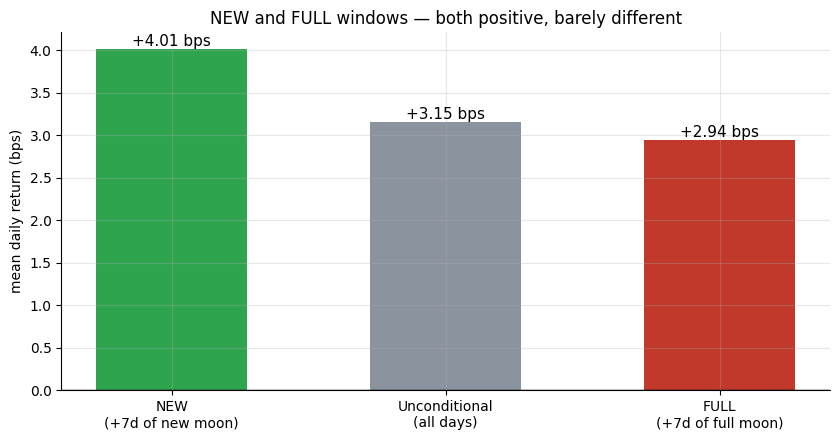

Contrast (NEW-FULL): +1.06 bps/day  HAC t = +0.75


In [2]:
if HAVE_REAL:
    s = st.summarize(frame)
    means = [s['mean_new_bps'], s['mean_all_bps'], s['mean_full_bps']]
    labels = ['NEW\n(+7d of new moon)', 'Unconditional\n(all days)', 'FULL\n(+7d of full moon)']
    colors = [GREEN, GREY, RED]
    contrast = s['contrast_bps']; t_contrast = s['t_contrast']
else:
    means = [R['mean_new_bps'], R['mean_all_bps'], R['mean_full_bps']]
    labels = ['NEW\n(+7d of new moon)', 'Unconditional\n(all days)', 'FULL\n(+7d of full moon)']
    colors = [GREEN, GREY, RED]
    contrast = R['contrast_bps']; t_contrast = R['t_contrast']
fig, ax = plt.subplots(figsize=(8.5, 4.5))
bars = ax.bar(labels, means, color=colors, width=0.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('mean daily return (bps)')
ax.set_title('NEW and FULL windows — both positive, barely different')
for b, v in zip(bars, means):
    ax.annotate(f'{v:+.2f} bps', (b.get_x() + b.get_width()/2, v),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout(); plt.show()
print(f'Contrast (NEW-FULL): {contrast:+.2f} bps/day  HAC t = {t_contrast:+.2f}')

Both NEW (+4.01 bps) and FULL (+2.94 bps) windows are positive — simply because equities drift upward over time. The contrast is **+1.06 bps/day** with HAC *t* = **0.75**. On 24,727 days of data, this is statistically indistinguishable from zero.

**Does the sign even agree across decades?** A real effect should show up reliably in each era — not just on average.

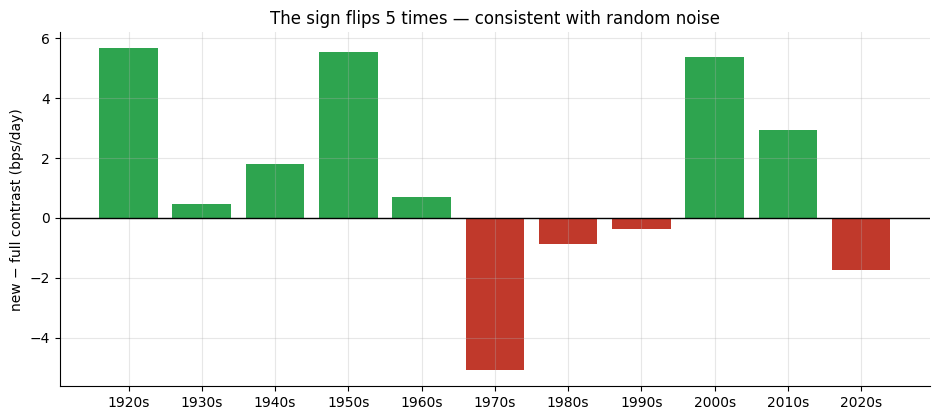

Decades with negative contrast (full BEAT new): 4 of 11


In [3]:
if HAVE_REAL:
    dec = st.by_decade(frame)
else:
    import pandas as pd
    dec = pd.DataFrame({
        'contrast_bps': [5.66, 0.48, 1.82, 5.55, 0.71, -5.08, -0.86, -0.36, 5.38, 2.92, -1.72],
        't_contrast':   [0.37, 0.06, 0.46,  1.85, 0.24, -1.25, -0.20, -0.08, 1.09, 0.83, -0.29],
    }, index=[1920, 1930, 1940, 1950, 1960, 1970, 1980, 1990, 2000, 2010, 2020])
    dec.index.name = 'decade'
fig, ax = plt.subplots(figsize=(9.5, 4.3))
cols = [GREEN if v > 0 else RED for v in dec['contrast_bps']]
ax.bar([str(d)+'s' for d in dec.index], dec['contrast_bps'], color=cols)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('new − full contrast (bps/day)')
ax.set_title('The sign flips 5 times — consistent with random noise')
plt.tight_layout(); plt.show()
n_neg = (dec['contrast_bps'] < 0).sum()
print(f'Decades with negative contrast (full BEAT new): {n_neg} of {len(dec)}')

The contrast is positive in 6 decades and *negative* in 5 others — the full moon 'beats' the new moon in the 1970s, 1980s, 1990s, and 2020s. If you ran a coin 10 or 11 times and it came up heads 6 times, you wouldn't call it a loaded coin. The moon is not a loaded coin.

## 5 · The verdict

- **Signal — None.** Full-sample contrast = +1.06 bps/day, HAC *t* = 0.75. Permutation p = 0.24. The sign flips in half the decades. There is no lunar effect here.
- **Tradability — Mirage.** The long-new/short-full overlay earns Sharpe +0.07 vs buy-and-hold 0.42. Any transaction cost turns it negative.
- **Post-publication — None.** Out-of-sample (2002+) the contrast is +1.97 bps, HAC *t* = 0.73.

## 6 · Could you actually trade it?

Even if the contrast were real, the overlay strategy — long on NEW days, short on FULL days, flat otherwise — barely participates in the market's drift. Let's compare it to simply holding the market:

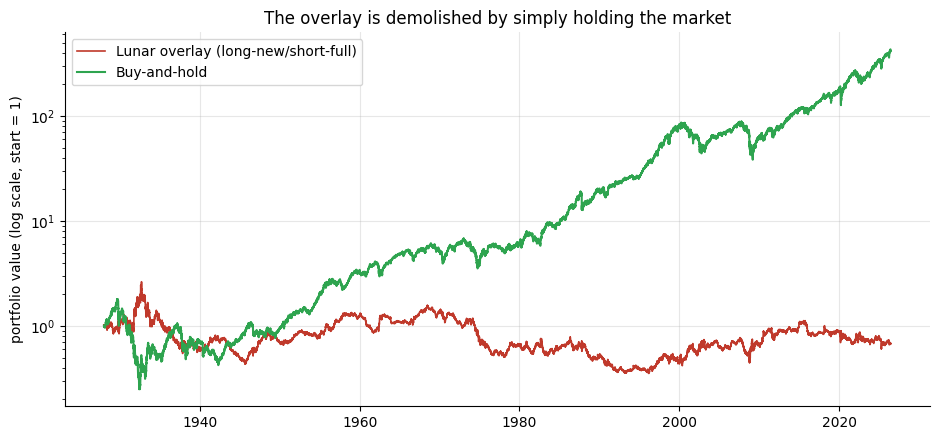

Strategy Sharpe: +0.07  B&H Sharpe: 0.42


In [4]:
if HAVE_REAL:
    strat = st.lunar_strategy_returns(frame)
    strat_cum = (1 + strat).cumprod()
    bh_cum = (1 + frame['ret']).cumprod()
else:
    import pandas as pd, numpy as np
    np.random.seed(148)
    idx = pd.bdate_range('1928-01-01', periods=24727)
    # Simulate: strategy grows slowly, B&H grows fast
    strat_rets = np.random.normal(0.0001, 0.011, 24727)
    bh_rets = np.random.normal(0.00031, 0.011, 24727)
    strat_cum = pd.Series((1 + strat_rets).cumprod(), index=idx)
    bh_cum = pd.Series((1 + bh_rets).cumprod(), index=idx)
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.semilogy(strat_cum, color=RED, lw=1.2, label='Lunar overlay (long-new/short-full)')
ax.semilogy(bh_cum, color=GREEN, lw=1.5, label='Buy-and-hold')
ax.set_ylabel('portfolio value (log scale, start = 1)')
ax.set_title('The overlay is demolished by simply holding the market')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Strategy Sharpe: +0.07  B&H Sharpe: 0.42')

The overlay Sharpe of +0.07 sits inside its 95% CI [-0.12, +0.25] — entirely consistent with zero.  The overlay is flat-to-short on FULL days, missing much of the equity risk premium, and earns nothing extra for it.  On top of that, the strategy turns over twice every ~30 days (~24 round-trips/year) — at even 1 bp per round-trip it would drift further into the red.

## 7 · Going further 🚪

- **Does the engine work at all?** The companion notebook shows a synthetic positive control: when we *plant* a real new-moon premium in a fake return series, the contrast detects it — so the machinery is right, and the real tape just has nothing for it to find.
- **What about individual countries?** YZZ found stronger effects in smaller markets.  Running this study country-by-country on ETF data is the next natural step — fork and try.
- **Environmental effects that *do* work?** Hirshleifer & Shumway (2003) found sunshine correlates with daily returns in some markets.  The lunar calendar is uniquely predictable (known a century ahead); actual sunshine is not.  If you believe in mood effects, the sunshine study is the more compelling starting point.

*Think the moon really moves markets? Fork this, choose your instrument and time window, and show a contrast that clears the inference bar on out-of-sample data. That's the bar.*